# Notebook 02b — Reconstrucción del baseline TF-IDF con dataset enriquecido

## Objetivo

El objetivo de este notebook es reconstruir el baseline TF-IDF utilizando el dataset enriquecido generado previamente.

En el Notebook 02 se había implementado una primera versión del buscador sobre un corpus reducido. Ese primer baseline fue útil para validar el pipeline completo:

- representación textual de películas,
- vectorización con TF-IDF,
- cálculo de similitud coseno,
- ranking de resultados,
- análisis cualitativo,
- evaluación con Precision@K.

Sin embargo, ese dataset inicial tenía un tamaño limitado y menor diversidad temática. Por eso, en el Notebook 01b se construyó un corpus más amplio y representativo, con aproximadamente 1000 películas, balanceado por géneros y años, y enriquecido con metadata adicional.

El objetivo de este notebook es analizar cómo se comporta el mismo enfoque TF-IDF cuando se aplica sobre un corpus más realista y mejor documentado.


## Contexto metodológico

TF-IDF es un enfoque léxico. Esto significa que la búsqueda depende principalmente de la coincidencia de términos entre la consulta del usuario y los textos del corpus.

En este proyecto, cada película se representa mediante la columna `search_text`, que combina información textual relevante como:

- título,
- overview,
- géneros,
- keywords,
- cast,
- directores,
- tagline.

Al enriquecer el texto disponible para cada película, se espera que TF-IDF tenga más oportunidades de encontrar coincidencias útiles. Aun así, el modelo seguirá teniendo una limitación importante: no comprende significado profundo, sino patrones de aparición de palabras.

Este notebook es importante porque permite construir un baseline léxico más sólido antes de avanzar al Notebook 3, donde se implementará búsqueda semántica con embeddings multilingües.

## Flujo general del notebook

```text
Dataset enriquecido
        ↓
Inspección del corpus
        ↓
Construcción de la matriz TF-IDF
        ↓
Representación vectorial de consultas
        ↓
Cálculo de similitud coseno
        ↓
Ranking de películas
        ↓
Análisis cualitativo
        ↓
Precision@K
        ↓
Comparación con el baseline original

## 1. Importación de librerías

Importamos las librerías necesarias para manipular el dataset, construir la representación TF-IDF, calcular similitud coseno y visualizar algunos aspectos del corpus.

In [1]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Herramientas de scikit-learn para TF-IDF y similitud coseno
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## 2. Carga del dataset enriquecido

Cargamos el dataset final generado en el Notebook 2.5.

Este archivo contiene aproximadamente 1000 películas y será la base para reconstruir el baseline TF-IDF en condiciones más realistas.

In [2]:
# Cargar el dataset enriquecido
url = "https://raw.githubusercontent.com/jiimedina/movie-semantic-search/refs/heads/main/data/movies_expanded_1000.csv"
df = pd.read_csv(url)

# Mostrar las primeras filas
df.head()

,id,title,original_title,overview,tagline,release_date,runtime,original_language,genres,keywords,cast,directors,popularity,vote_average,vote_count,overview_length,release_year,search_text,search_text_length
0,10576,Psycho II,Psycho II,Norman Bates is declared sane and released fro...,"It's 22 years later, and Norman Bates is comin...",1983-06-03,113,en,"['Horror', 'Mystery', 'Thriller', 'Crime']","['psychopath', 'insanity', 'motel', 'sequel', ...","['Anthony Perkins', 'Meg Tilly', 'Vera Miles',...",['Richard Franklin'],2.7056,6.510,724,204,1983,Psycho II | Norman Bates is declared sane and ...,572
1,10830,Matilda,Matilda,Matilda Wormwood is an brilliant and intellige...,Somewhere inside all of us is the power to cha...,1996-08-02,98,en,"['Comedy', 'Family', 'Fantasy']","['based on novel or book', 'parent child relat...","['Mara Wilson', 'Danny DeVito', 'Rhea Perlman'...",['Danny DeVito'],11.4750,7.174,4785,413,1996,Matilda | Matilda Wormwood is an brilliant and...,1033
2,89,Indiana Jones and the Last Crusade,Indiana Jones and the Last Crusade,"In 1938, an art collector appeals to eminent a...",Have the adventure of your life keeping up wit...,1989-05-24,127,en,"['Adventure', 'Action']","['saving the world', 'nazi', 'holy grail', 've...","['Harrison Ford', 'Sean Connery', 'Denholm Ell...",['Steven Spielberg'],7.2998,7.852,11019,625,1989,"Indiana Jones and the Last Crusade | In 1938, ...",1328
3,12155,Alice in Wonderland,Alice in Wonderland,"Alice, now 19 years old, returns to the whimsi...",You're invited to a very important date.,2010-03-03,108,en,"['Family', 'Fantasy', 'Adventure']","['based on novel or book', 'queen', ""based on ...","['Mia Wasikowska', 'Johnny Depp', 'Anne Hathaw...",['Tim Burton'],10.4469,6.639,14744,139,2010,"Alice in Wonderland | Alice, now 19 years old,...",638
4,11186,Child's Play 2,Child's Play 2,Chucky is reconstructed by a toy factory to di...,Sorry Jack... Chucky's back!,1990-11-09,84,en,['Horror'],"['factory', 'voodoo', 'foster parents', 'faith...","['Alex Vincent', 'Brad Dourif', 'Christine Eli...",['John Lafia'],4.8559,6.359,2005,172,1990,Child's Play 2 | Chucky is reconstructed by a ...,638


## 3. Inspección inicial del dataset

Antes de construir la matriz TF-IDF, revisamos la estructura del dataset.

En particular, nos interesa verificar:

- cantidad de películas disponibles,
- columnas presentes,
- existencia de valores nulos,
- calidad de la columna `search_text`,
- ejemplos reales del texto que será usado por el buscador.

In [29]:
# Cantidad de filas y columnas
df.shape

(1000, 20)

In [30]:
# Columnas disponibles
df.columns

Index(['id', 'title', 'original_title', 'overview', 'tagline', 'release_date',
       'runtime', 'original_language', 'genres', 'keywords', 'cast',
       'directors', 'popularity', 'vote_average', 'vote_count',
       'overview_length', 'release_year', 'search_text', 'search_text_length',
       'text_length'],
      dtype='object')

In [31]:
# Vista general de tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  1000 non-null   int64  
 1   title               1000 non-null   object 
 2   original_title      1000 non-null   object 
 3   overview            1000 non-null   object 
 4   tagline             914 non-null    object 
 5   release_date        1000 non-null   object 
 6   runtime             1000 non-null   int64  
 7   original_language   1000 non-null   object 
 8   genres              1000 non-null   object 
 9   keywords            1000 non-null   object 
 10  cast                1000 non-null   object 
 11  directors           1000 non-null   object 
 12  popularity          1000 non-null   float64
 13  vote_average        1000 non-null   float64
 14  vote_count          1000 non-null   int64  
 15  overview_length     1000 non-null   int64  
 16  release

In [32]:
# Revisar valores nulos en la columna principal de búsqueda
df["search_text"].isna().sum()

np.int64(0)

In [35]:
# Asegurar que search_text sea texto válido
# Si aparece algún valor nulo, lo reemplazamos por string vacío para evitar errores en TF-IDF.
df["search_text"] = df["search_text"].fillna("").astype(str)

In [34]:
# Ver ejemplos reales de search_text
df["search_text"].head(3).tolist()

["Psycho II | Norman Bates is declared sane and released from the facility in which he was being held, despite the complaints of Lila Loomis, sister of his most famous victim. Is he really cured, or will he kill again? | Tagline: It's 22 years later, and Norman Bates is coming home. | Genres: Horror, Mystery, Thriller, Crime | Keywords: psychopath, insanity, motel, sequel, revenge, murder, mental illness, framed for murder, voyeur, mother son relationship, admiring | Cast: Anthony Perkins, Meg Tilly, Vera Miles, Robert Loggia, Dennis Franz | Director: Richard Franklin",
 'Matilda | Matilda Wormwood is an brilliant and intelligent little girl. Unfortunately, her parents, Harry and Zinnia, fail to see that fact. As time passes, she finally starts school and has a kind teacher, loyal friends, and a terrifying, sadistic headmistress. As she becomes fed up with the constant cruelty, she discovers she has a special gift that she just might be able to use to outwit the unruly adults around he

### Observaciones iniciales del dataset

El dataset enriquecido contiene 1000 películas y 20 columnas.

A diferencia del dataset inicial utilizado en el baseline original, este corpus incluye mayor cantidad de metadata textual, como `tagline`, `keywords`, `cast`, `directors`, `genres` y una columna consolidada llamada `search_text`.

La columna `search_text` no presenta valores nulos, por lo que puede utilizarse directamente como entrada para TF-IDF.

También se observa que `tagline` tiene algunos valores faltantes, lo cual no representa un problema porque ya fue integrada previamente dentro de `search_text` solo cuando estaba disponible.

Los primeros ejemplos de `search_text` muestran que cada película está representada por una combinación de título, overview, tagline, géneros, keywords, elenco y director. Esto genera documentos más ricos y descriptivos para el sistema de recuperación.

## 4. Exploración del corpus textual

Como ahora trabajamos con un corpus más grande y enriquecido, conviene observar algunas características básicas de los textos.

Esto permite entender mejor qué información está recibiendo TF-IDF y cómo cambió el escenario respecto al baseline original.

In [36]:
# Longitud de cada search_text en cantidad de caracteres
df["text_length"] = df["search_text"].str.len()

# Estadísticas descriptivas de longitud textual
df["text_length"].describe()

,text_length
count,1000.000000
mean,703.231000
std,183.782354
min,280.000000
25%,576.750000
50%,688.500000
75%,808.500000
max,1669.000000


### Estadísticas descriptivas

Las estadísticas muestran que:

- la longitud promedio de `search_text` es de aproximadamente 703 caracteres,
- el dataset presenta una variabilidad moderada,
- y no existen documentos extremadamente pequeños o vacíos.

Esto es importante porque TF-IDF depende directamente de la calidad y cantidad de texto disponible para representar cada película.

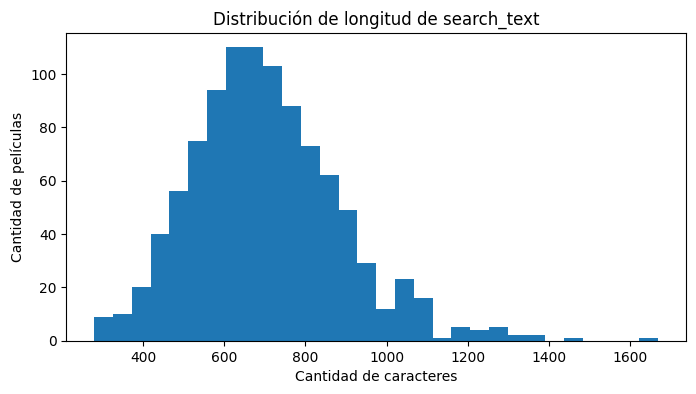

In [6]:
# Visualizar distribución de longitudes de search_text
plt.figure(figsize=(8, 4))
plt.hist(df["text_length"], bins=30)
plt.title("Distribución de longitud de search_text")
plt.xlabel("Cantidad de caracteres")
plt.ylabel("Cantidad de películas")
plt.show()

### Distribución de longitud de `search_text`

El histograma muestra la distribución de tamaños de los documentos textuales dentro del corpus.

La mayoría de las películas poseen textos con una longitud intermedia, concentrándose aproximadamente entre 500 y 900 caracteres.

También se observan algunos casos extremos:
- películas con descripciones relativamente cortas,
- y otras con metadata mucho más extensa.

Este comportamiento es esperable en datasets reales, ya que algunas películas poseen overviews más detallados y mayor cantidad de keywords o metadata asociada.

La longitud de `search_text` es relevante porque TF-IDF depende directamente del texto disponible.

Un texto demasiado corto puede limitar la recuperación, ya que contiene pocas palabras para comparar contra las consultas. En cambio, un texto enriquecido con keywords, cast, directores y tagline puede aportar señales adicionales para el ranking.

In [7]:
# Películas con textos más cortos
short_texts = df.sort_values("text_length")[["title", "release_year", "text_length", "search_text"]].head(10)
short_texts

,title,release_year,text_length,search_text
576,Buddy Goes West,1981,280,Buddy Goes West | Outlaw drifter Buddy is mist...
189,The Duel,2016,290,The Duel | A Texas Ranger investigates a serie...
440,Lucky Luke: Daltons on the Loose,1983,291,Lucky Luke: Daltons on the Loose | The cowboy ...
533,Guinea Pig: Devil's Experiment,1985,297,Guinea Pig: Devil's Experiment | Masked thugs ...
348,Lucky Luke,2009,302,"Lucky Luke | Fearless gunslinger, Lucky Luke, ..."
748,Terror on the Prairie,2022,317,Terror on the Prairie | A pioneering family fi...
520,The Emoji Movie,2017,322,"The Emoji Movie | Gene, a multi-expressional e..."
514,The Tit and the Moon,1994,325,The Tit and the Moon | A child does not stand ...
876,Fib the Truth,2021,325,Fib the Truth | A couple in love spends time a...
968,The Cowboy and the Frenchman,1988,336,"The Cowboy and the Frenchman | A grizzled, har..."


### Películas con textos más cortos

Las películas con menor longitud textual suelen tener:

- overviews breves,
- pocas keywords,
- o metadata limitada.

En algunos casos, esto podría afectar negativamente la capacidad de TF-IDF para recuperar correctamente estas películas frente a ciertas consultas.

In [8]:
# Películas con textos más largos
long_texts = df.sort_values("text_length", ascending=False)[["title", "release_year", "text_length", "search_text"]].head(10)
long_texts

,title,release_year,text_length,search_text
498,Smile 2,2024,1669,"Smile 2 | About to embark on a new world tour,..."
399,Twelve Monkeys,1995,1478,"Twelve Monkeys | In the year 2035, convict Jam..."
919,Silent Hill,2006,1379,"Silent Hill | Rose, a desperate mother, takes ..."
230,War for the Planet of the Apes,2017,1358,War for the Planet of the Apes | Caesar and hi...
2,Indiana Jones and the Last Crusade,1989,1328,"Indiana Jones and the Last Crusade | In 1938, ..."
28,How to Train Your Dragon 2,2014,1317,How to Train Your Dragon 2 | Five years after ...
62,The Bone Collector,1999,1278,The Bone Collector | Lincoln Rhyme was the dep...
321,National Treasure,2004,1277,"National Treasure | Modern treasure hunters, l..."
963,Double Jeopardy,1999,1264,"Double Jeopardy | Libby Parsons, wrongly convi..."
816,The Shining,1980,1258,The Shining | Jack Torrance accepts a caretake...


### Películas con textos más largos

Las películas con mayor longitud textual contienen:

- descripciones extensas,
- numerosas keywords,
- mayor cantidad de metadata semántica.

Esto puede beneficiar a TF-IDF porque existen más términos disponibles para establecer coincidencias con las consultas.

Sin embargo, documentos excesivamente largos también pueden introducir ruido o términos menos relevantes.

## Conclusiones de la exploración textual

El análisis muestra que el corpus enriquecido posee una representación textual mucho más completa que el dataset original utilizado en el primer baseline.

La combinación de overview, keywords, géneros, elenco y directores produce documentos ricos en información semántica y descriptiva.

Esto permitirá evaluar cómo impacta la calidad del corpus sobre el desempeño de un enfoque léxico tradicional como TF-IDF.

## 5. Construcción de la matriz TF-IDF

En esta etapa transformamos la columna `search_text` en una matriz numérica.

Cada fila representa una película y cada columna representa un término del vocabulario aprendido por TF-IDF.

El valor de cada celda indica qué tan importante es un término para una película, considerando:

- su frecuencia dentro del texto de esa película,
- y qué tan común o raro es ese término en el corpus completo.

Para este baseline se utilizan algunos parámetros simples:

- `stop_words="english"`: elimina palabras frecuentes del inglés con poco valor semántico,
- `max_features=10000`: limita el vocabulario a los términos más informativos,
- `ngram_range=(1, 2)`: permite considerar palabras individuales y pares de palabras.

El uso de bigramas puede ser útil para expresiones como `science fiction`, `serial killer`, `space mission` o `romantic comedy`.

In [9]:
# Definir el vectorizador TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1, 2)
)

# Construir la matriz TF-IDF a partir de search_text
tfidf_matrix = vectorizer.fit_transform(df["search_text"])

# Ver dimensiones de la matriz
# Filas: películas
# Columnas: términos del vocabulario TF-IDF
tfidf_matrix.shape

(1000, 10000)

La matriz resultante representa el corpus en forma vectorial.

A partir de este punto, cada película puede compararse con una consulta del usuario usando similitud coseno.

## 6. Exploración del vocabulario TF-IDF

Antes de implementar la búsqueda, revisamos algunos términos aprendidos por el vectorizador.

Cada término del vocabulario representa una dimensión dentro del espacio vectorial utilizado para comparar películas y consultas.

- cada palabra o combinación de palabras (n-grama),
- se convierte en una característica numérica,
- cuyo peso depende de su importancia dentro del corpus.

In [10]:
# Obtener vocabulario aprendido por TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Cantidad total de términos en el vocabulario
len(feature_names)

10000

In [11]:
# Mostrar una muestra de términos del vocabulario
feature_names[:50]

array(['000', '000 years', '10', '11', '11 year', '11th', '12', '12 year',
       '13', '13th', '14th', '14th century', '15', '15 year', '15th',
       '15th century', '17', '17 year', '1870s', '18th', '18th century',
       '1900s', '1910s', '1920s', '1926', '1930s', '1937', '1940s',
       '1940s cast', '1945', '1950s', '1950s 1960s', '1960s', '1970s',
       '1980s', '1990s', '19th', '19th century', '2000s', '2010s',
       '2020s', '2021', '2030s', '2040s', '20th', '20th century', '22',
       '28', '30', '300'], dtype=object)

### Muestra del vocabulario generado

Los primeros términos del vocabulario muestran que TF-IDF aprendió palabras provenientes de:

- descripciones,
- géneros,
- keywords,
- fechas,
- expresiones temporales,
- y metadata adicional.

También se observan términos compuestos como:

- `14th century`
- `15 year`
- `20th century`

Esto ocurre porque el vectorizador fue configurado para utilizar n-gramas, permitiendo representar pequeñas secuencias de palabras además de términos individuales.

El uso de n-gramas ayuda a capturar expresiones con significado más específico que las palabras aisladas.

In [12]:
# Calcular la suma de pesos TF-IDF de cada término en todo el corpus
term_scores = np.asarray(tfidf_matrix.sum(axis=0)).ravel()

# Crear dataframe con términos y sus puntajes acumulados
terms_df = pd.DataFrame({
    "term": feature_names,
    "tfidf_score": term_scores
})

# Términos con mayor peso acumulado
terms_df.sort_values("tfidf_score", ascending=False).head(30)

,term,tfidf_score
9682,war,22.759596
2389,director,20.682905
1467,cast,20.107738
3374,genres,20.035969
4895,keywords,19.883845
9042,tagline,19.504777
2992,family,16.990239
85,action,16.767328
763,based,16.368550
2593,drama,15.723794


### Términos con mayor peso acumulado

El siguiente análisis muestra qué términos poseen mayor peso TF-IDF acumulado dentro del corpus completo.

Esto permite identificar:

- conceptos frecuentes,
- temas dominantes,
- y patrones generales del dataset.

Se observa que muchos de los términos con mayor peso corresponden a:

- géneros cinematográficos (`action`, `drama`, `comedy`, `thriller`),
- conceptos narrativos frecuentes (`war`, `love`, `family`, `world`),
- y metadata incorporada en `search_text` (`director`, `cast`, `genres`, `keywords`, `tagline`).

Esto confirma que el enriquecimiento realizado en el Notebook 02b tuvo un impacto directo sobre el espacio textual representado por TF-IDF.

Ahora el modelo no depende únicamente de la sinopsis (`overview`), sino también de múltiples fuentes complementarias de información semántica.

## 7. Sistema de búsqueda con TF-IDF

Ahora implementamos una función de búsqueda.

El procedimiento será:

1. recibir una consulta en lenguaje natural,
2. transformar esa consulta usando el mismo vectorizador TF-IDF,
3. calcular similitud coseno entre la consulta y todas las películas,
4. ordenar las películas por similitud descendente,
5. devolver las primeras posiciones del ranking.

In [13]:
def search_movies_tfidf(query, top_k=10):
    """
    Busca películas relevantes para una consulta usando TF-IDF y similitud coseno.

    Parámetros:
    - query: consulta del usuario en lenguaje natural
    - top_k: cantidad de resultados a devolver

    Retorna:
    - DataFrame con las películas mejor posicionadas y su score de similitud
    """

    # Transformar la consulta al mismo espacio vectorial que el corpus
    query_vector = vectorizer.transform([query])

    # Calcular similitud coseno entre la consulta y todas las películas
    similarity_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    # Obtener índices de las películas ordenadas por similitud descendente
    top_indices = similarity_scores.argsort()[::-1][:top_k]

    # Seleccionar columnas útiles para analizar resultados
    results = df.iloc[top_indices].copy()
    results["score"] = similarity_scores[top_indices]

    columns_to_show = [
        "title",
        "release_year",
        "genres",
        "overview",
        "keywords",
        "cast",
        "directors",
        "score"
    ]

    # Mantener solo columnas que existan en el dataset
    columns_to_show = [col for col in columns_to_show if col in results.columns]

    return results[columns_to_show]


In [14]:
# Primera prueba rápida
search_movies_tfidf("space adventure aliens", top_k=5)

,title,release_year,genres,overview,keywords,cast,directors,score
675,Interstellar,2014,"['Adventure', 'Drama', 'Science Fiction']",The adventures of a group of explorers who mak...,"['rescue', 'future', 'spacecraft', 'race again...","['Matthew McConaughey', 'Anne Hathaway', 'Mich...",['Christopher Nolan'],0.223731
379,Aliens,1986,"['Action', 'Thriller', 'Science Fiction']","Ripley, the sole survivor of the Nostromo's de...","['android', 'space marine', 'extraterrestrial ...","['Sigourney Weaver', 'Carrie Henn', 'Michael B...",['James Cameron'],0.190890
372,Elio,2025,"['Adventure', 'Animation', 'Comedy', 'Family',...","Elio, a space fanatic with an active imaginati...","['villain', 'alien', 'coming of age', 'compute...","['Yonas Kibreab', 'Remy Edgerly', 'Zoe Saldaña...","['Madeline Sharafian', 'Domee Shi', 'Adrian Mo...",0.173846
782,District 9,2009,['Science Fiction'],"Thirty years ago, aliens arrive on Earth. Not ...","['street gang', 'government', 'genetics', 'slu...","['Sharlto Copley', 'Jason Cope', 'Nathalie Bol...",['Neill Blomkamp'],0.170666
771,Alien: Romulus,2024,"['Horror', 'Science Fiction']",While scavenging the deep ends of a derelict s...,"['alien life-form', 'spin off', 'alien contact...","['Cailee Spaeny', 'David Jonsson', 'Archie Ren...",['Fede Álvarez'],0.157910


### Primera prueba del sistema de búsqueda

La consulta utilizada fue:

`space adventure aliens`

Los resultados recuperados muestran películas relacionadas con ciencia ficción, espacio, extraterrestres y aventura.

Entre los primeros resultados aparecen títulos como `Interstellar`, `Aliens`, `Elio`, `District 9` y `Alien: Romulus`.

Esto indica que el sistema TF-IDF logra capturar coincidencias léxicas relevantes asociadas a términos como `space`, `adventure`, `alien` y `aliens`.

En este caso, el ranking parece razonable, ya que las películas recuperadas comparten elementos temáticos claros con la consulta.

Es importante recordar que TF-IDF no comprende el significado profundo de la consulta.

El sistema recupera documentos en función de coincidencias de términos ponderadas. Por eso, cuando las palabras de la consulta aparecen en el `search_text` de las películas, el método puede funcionar muy bien.

Sin embargo, si una consulta expresa una idea con palabras distintas a las presentes en el corpus, el rendimiento puede disminuir.

Con esta función queda implementado el sistema de búsqueda TF-IDF sobre el dataset enriquecido.

A partir de este punto, se pueden realizar pruebas cualitativas con distintos tipos de consultas para analizar fortalezas y limitaciones del enfoque léxico.

## 8. Análisis cualitativo de resultados

Probamos el buscador con distintas consultas para observar su comportamiento.

En esta etapa no buscamos todavía una métrica numérica, sino analizar si los resultados tienen sentido desde una perspectiva humana.

Vamos a probar consultas de distintos tipos:

- consultas con términos concretos,
- consultas temáticas,
- consultas ambiguas,
- consultas en español.

Las consultas en español son especialmente importantes para el proyecto, porque el dataset está mayormente en inglés. TF-IDF no es multilingüe, por lo que se espera que tenga dificultades cuando las palabras de la consulta no coincidan con las palabras del corpus.

In [15]:
# Consulta concreta con términos probablemente presentes en el corpus
search_movies_tfidf("roman general revenge", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
359,War Machine,2017,"['Comedy', 'Drama', 'War']",A rock star general bent on winning the “impos...,"['journalist', 'based on novel or book', 'afgh...","['Brad Pitt', 'Anthony Michael Hall', 'Emory C...",['David Michôd'],0.215756
159,The Passion of the Christ,2004,['Drama'],A graphic portrayal of the last twelve hours o...,"['mission', 'suffering', 'roman empire', 'chri...","['Jim Caviezel', 'Maia Morgenstern', 'Christo ...",['Mel Gibson'],0.174643
319,Sniper: The White Raven,2022,"['War', 'Action', 'Drama']",Mykola is an eccentric pacifist who wants to b...,"['eastern europe', 'europe', 'donbass war', 'r...","['Pavlo Aldoshyn', 'Maryna Koshkina', 'Andrii ...",['Marian Bushan'],0.144858
964,King Arthur,2004,"['Adventure', 'War', 'History', 'Action', 'Dra...","The story of the Arthurian legend, based on th...","['roman empire', 'king arthur', 'battle', '5th...","['Clive Owen', 'Ioan Gruffudd', 'Keira Knightl...",['Antoine Fuqua'],0.144168
16,Antz,1998,"['Animation', 'Comedy', 'Family']",A neurotic worker ant in love with a rebelliou...,"['princess', 'work', 'worker', 'hero', 'genera...","['Woody Allen', 'Sharon Stone', 'Dan Aykroyd',...","['Eric Darnell', 'Tim Johnson']",0.142076
380,Gettysburg,1993,"['Drama', 'History', 'War']","In the summer of 1863, General Robert E. Lee l...","['army', 'civil war', 'independence', 'troops'...","['Jeff Daniels', 'Tom Berenger', 'Martin Sheen...",['Ronald F. Maxwell'],0.109875
802,I Spit on Your Grave,2010,"['Thriller', 'Crime', 'Horror']","A beautiful woman from the city, Jennifer Hill...","['rape', 'fondling', 'remake', 'revenge', 'wri...","['Sarah Butler', 'Jeff Branson', 'Tracey Walte...",['Steven R. Monroe'],0.108537
82,Kingdom III: The Flame of Destiny,2023,"['Action', 'Adventure', 'War']",To defend their kingdom against a sudden invas...,"['based on manga', 'epic battle', 'warring sta...","['Kento Yamazaki', 'Ryo Yoshizawa', 'Kanna Has...",['Shinsuke Sato'],0.100238
156,Once Upon a Time in Mexico,2003,"['Action', 'Crime', 'Thriller', 'Western']",A corrupt CIA agent Sands hires hitman El Mari...,"['central intelligence agency (cia)', 'mexico'...","['Antonio Banderas', 'Johnny Depp', 'Cheech Ma...",['Robert Rodriguez'],0.081385
569,Furious 7,2015,"['Action', 'Crime', 'Thriller']",Deckard Shaw seeks revenge against Dominic Tor...,"['car race', 'speed', 'street race', 'revenge'...","['Vin Diesel', 'Paul Walker', 'Dwayne Johnson'...",['James Wan'],0.078435


### Consulta concreta

La consulta:

`roman general revenge`

busca una combinación relativamente específica de conceptos históricos y narrativos.

Los resultados muestran un comportamiento parcialmente correcto:

- aparecen películas relacionadas con guerras o imperios (`King Arthur`, `The Passion of the Christ`),
- y también películas asociadas al concepto de `revenge`.

Sin embargo, el ranking no recupera inmediatamente películas como `Gladiator`, que intuitivamente serían altamente relevantes.

Esto refleja una característica importante de TF-IDF:

el sistema depende fuertemente de las palabras exactas presentes en el corpus.

Si ciertos términos no aparecen explícitamente en el `search_text`, la similitud puede verse afectada incluso cuando la temática general coincide.

In [16]:
# Consulta temática sobre ciencia ficción
search_movies_tfidf("space mission alien planet", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
771,Alien: Romulus,2024,"['Horror', 'Science Fiction']",While scavenging the deep ends of a derelict s...,"['alien life-form', 'spin off', 'alien contact...","['Cailee Spaeny', 'David Jonsson', 'Archie Ren...",['Fede Álvarez'],0.247371
279,Spaceballs,1987,"['Comedy', 'Science Fiction']",When the nefarious Dark Helmet hatches a plan ...,"['galaxy', 'android', 'space marine', 'laser g...","['Mel Brooks', 'John Candy', 'Rick Moranis', '...",['Mel Brooks'],0.223261
587,Armageddon,1998,"['Action', 'Thriller', 'Science Fiction', 'Adv...",When an asteroid threatens to collide with Ear...,"['daughter', 'race against time', 'space marin...","['Bruce Willis', 'Billy Bob Thornton', 'Ben Af...",['Michael Bay'],0.199295
278,Dragon Ball Z: Bardock - The Father of Goku,1990,"['Animation', 'Action', 'Science Fiction', 'Dr...","Bardock, Son Goku's father, is a low-ranking S...","['precognition', 'alien', 'prequel', 'based on...","['Masako Nozawa', 'Kazuyuki Sogabe', 'Yuko Mit...",['Mitsuo Hashimoto'],0.197731
491,Life,2017,"['Horror', 'Science Fiction', 'Mystery']",The six-member crew of the International Space...,"['planet mars', 'alien life-form', 'space', 'a...","['Jake Gyllenhaal', 'Ryan Reynolds', 'Rebecca ...",['Daniel Espinosa'],0.192906
253,Man of Steel,2013,"['Action', 'Adventure', 'Science Fiction']",A young boy learns that he has extraordinary p...,"['saving the world', 'flying', 'hope', 'superh...","['Henry Cavill', 'Amy Adams', 'Russell Crowe',...",['Zack Snyder'],0.186997
714,Predator: Badlands,2025,"['Action', 'Science Fiction', 'Adventure']","Cast out from his clan, a young Predator finds...","['outcast', 'alien planet', 'team up', 'vibran...","['Elle Fanning', 'Dimitrius Schuster-Koloamata...",['Dan Trachtenberg'],0.185971
169,Alien: Covenant,2017,"['Horror', 'Science Fiction']","The crew of the colony ship Covenant, bound fo...","['android', 'spacecraft', 'experiment', 'space...","['Michael Fassbender', 'Katherine Waterston', ...",['Ridley Scott'],0.180029
780,Rogue One: A Star Wars Story,2016,"['Action', 'Adventure', 'Science Fiction']",A rogue band of resistance fighters unite for ...,"['rebellion', 'spacecraft', 'rebel', 'space ba...","['Felicity Jones', 'Diego Luna', 'Alan Tudyk',...",['Gareth Edwards'],0.178504
379,Aliens,1986,"['Action', 'Thriller', 'Science Fiction']","Ripley, the sole survivor of the Nostromo's de...","['android', 'space marine', 'extraterrestrial ...","['Sigourney Weaver', 'Carrie Henn', 'Michael B...",['James Cameron'],0.175419


### Consulta temática de ciencia ficción

En esta consulta, TF-IDF muestra un comportamiento considerablemente mejor.

Los resultados recuperados contienen múltiples películas relacionadas con:

- exploración espacial,
- extraterrestres,
- viajes interplanetarios,
- y ciencia ficción.

Películas como:

- `Alien: Romulus`,
- `Life`,
- `Alien: Covenant`,
- `Aliens`,
- `Rogue One`

comparten numerosos términos explícitos con la consulta.

Esto favorece a TF-IDF, ya que el enfoque léxico funciona especialmente bien cuando existe fuerte superposición de vocabulario entre consulta y documentos.

In [17]:
# Consulta de crimen / investigación
search_movies_tfidf("detective investigates serial killer", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
62,The Bone Collector,1999,"['Crime', 'Thriller', 'Drama', 'Mystery']",Lincoln Rhyme was the department's top homicid...,"['new york city', 'taxi', 'based on novel or b...","['Denzel Washington', 'Angelina Jolie', 'Queen...",['Phillip Noyce'],0.273773
687,Mindhunters,2004,"['Mystery', 'Thriller', 'Crime']",Trainees in the FBI's psychological profiling ...,"['island', 'fbi', 'simulation', 'training', 's...","['Kathryn Morris', 'Jonny Lee Miller', 'LL Coo...",['Renny Harlin'],0.268413
606,Se7en,1995,"['Crime', 'Mystery', 'Thriller']",Two homicide detectives are on a desperate hun...,"['rage and hate', 'police', 's.w.a.t.', 'sadis...","['Morgan Freeman', 'Brad Pitt', 'Gwyneth Paltr...",['David Fincher'],0.241849
686,Kiss the Girls,1997,"['Thriller', 'Crime', 'Mystery', 'Drama']",Forensic psychologist and detective Alex Cross...,"['based on novel or book', 'escape', 'kidnappi...","['Morgan Freeman', 'Ashley Judd', 'Cary Elwes'...",['Gary Fleder'],0.233354
325,Cruising,1980,"['Crime', 'Mystery', 'Thriller']",When New York is caught in the grip of a sadis...,"['new york city', 'police', 'undercover', 'hom...","['Al Pacino', 'Paul Sorvino', 'Karen Allen', '...",['William Friedkin'],0.217310
689,Dangerous Animals,2025,"['Horror', 'Thriller']",A savvy and free-spirited surfer is abducted b...,"['shark attack', 'animal attack', 'tape', 'ser...","['Hassie Harrison', 'Jai Courtney', 'Josh Heus...",['Sean Byrne'],0.210570
690,The Batman,2022,"['Crime', 'Mystery', 'Thriller']","In his second year of fighting crime, Batman u...","['police', 'psychopath', 'secret identity', 'c...","['Robert Pattinson', 'Zoë Kravitz', 'Jeffrey W...",['Matt Reeves'],0.194770
351,Striking Distance,1993,"['Crime', 'Action', 'Mystery', 'Thriller']","Coming from a police family, Tom Hardy ends up...","['boat', 'observer', 'serial killer', 'homicid...","['Bruce Willis', 'Sarah Jessica Parker', 'Denn...",['Rowdy Herrington'],0.194681
633,Zodiac,2007,"['Crime', 'Mystery', 'Thriller']","Over the course of a decade, editors of the Sa...","['newspaper', 'journalist', 'california', 'bas...","['Jake Gyllenhaal', 'Mark Ruffalo', 'Anthony E...",['David Fincher'],0.188665
299,Saw X,2023,"['Horror', 'Mystery']","Between the events of 'Saw' and 'Saw II', a si...","['mexico', 'mexico city, mexico', 'sadism', 'r...","['Tobin Bell', 'Shawnee Smith', 'Synnøve Macod...",['Kevin Greutert'],0.177809


### Consulta de crimen e investigación

La consulta:

`detective investigates serial killer`

produce resultados altamente coherentes.

Películas como:

- `Se7en`,
- `Zodiac`,
- `The Bone Collector`,
- `Kiss the Girls`

comparten conceptos narrativos muy específicos asociados a:

- detectives,
- homicidios,
- investigaciones criminales,
- asesinos seriales.

Este tipo de consultas beneficia particularmente a TF-IDF porque suelen contener vocabulario altamente discriminativo dentro del corpus.

In [18]:
# Consulta sobre romance
search_movies_tfidf("romantic relationship love story", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
301,Her,2013,"['Romance', 'Science Fiction', 'Drama']","In the not so distant future, Theodore, a lone...","['future', 'artificial intelligence (a.i.)', '...","['Joaquin Phoenix', 'Scarlett Johansson', 'Lyn...",['Spike Jonze'],0.285004
403,20th Century Girl,2022,"['Romance', 'Drama']","In 1999, a teen girl keeps close tabs on a boy...","['friendship', 'love triangle', 'melancholy', ...","['Kim Yoo-jung', 'Byeon Woo-seok', 'Park Jung-...",['Bang Woo-ri'],0.264691
628,The Notebook,2004,"['Romance', 'Drama']",An epic love story centered around an older ma...,"['secret love', 'soulmates', 'based on novel o...","['Ryan Gosling', 'Rachel McAdams', 'Gena Rowla...",['Nick Cassavetes'],0.221202
110,Deep Water,2022,"['Drama', 'Mystery', 'Thriller']",A well-to-do husband who allows his wife to ha...,"['infidelity', 'jealousy', 'based on novel or ...","['Ben Affleck', 'Ana de Armas', 'Tracy Letts',...",['Adrian Lyne'],0.164649
812,Beauty and the Beast,1991,"['Romance', 'Family', 'Animation', 'Fantasy']","Follow the adventures of Belle, a bright young...","['princess', 'france', 'prince', 'castle', 'vi...","[""Paige O'Hara"", 'Robby Benson', 'Richard Whit...","['Gary Trousdale', 'Kirk Wise']",0.157828
972,Edward Scissorhands,1990,"['Fantasy', 'Drama', 'Romance']",A small suburban town receives a visit from a ...,"['underdog', 'small town', 'unsociability', 'i...","['Johnny Depp', 'Winona Ryder', 'Dianne Wiest'...",['Tim Burton'],0.147628
683,Your Fault,2024,"['Drama', 'Romance']",The love between Noah and Nick seems unwaverin...,"['based on novel or book', 'suicide attempt', ...","['Nicole Wallace', 'Gabriel Guevara', 'Marta H...",['Domingo González'],0.132783
472,Regretting You,2025,"['Romance', 'Drama']",Morgan Grant and her daughter Clara explore wh...,"['high school', 'based on novel or book', 'aun...","['Mckenna Grace', 'Mason Thames', 'Allison Wil...",['Josh Boone'],0.125351
592,It Ends with Us,2024,"['Drama', 'Romance']",When a woman's first love suddenly reenters he...,"['based on novel or book', 'love triangle', 'a...","['Blake Lively', 'Justin Baldoni', 'Jenny Slat...",['Justin Baldoni'],0.124949
469,Three Steps Above Heaven,2010,"['Romance', 'Drama']","Babi, a sheltered upper-class girl, and Hache,...","['friendship', 'based on novel or book', 'rebe...","['Mario Casas', 'María Valverde', 'Álvaro Cerv...",['Fernando González Molina'],0.114136


### Consulta romántica

La consulta romántica también produce resultados razonables.

Películas como:

- `Her`,
- `The Notebook`,
- `20th Century Girl`

contienen términos fuertemente asociados a relaciones amorosas y drama romántico.

Además, se observa que las keywords enriquecidas ayudan considerablemente al modelo, ya que muchas películas incluyen explícitamente términos como:

- `love`,
- `relationship`,
- `romance`,
- `couple`,
- `love story`.

Esto muestra uno de los beneficios del enriquecimiento textual realizado en el Notebook 2.5.

In [19]:
# Consulta más abstracta
search_movies_tfidf("a movie about dreams and reality", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
744,The Thirteenth Floor,1999,"['Thriller', 'Science Fiction', 'Mystery']","In Los Angeles, a wealthy man, known as Mr. Fu...","['artificial intelligence (a.i.)', 'based on n...","['Craig Bierko', 'Armin Mueller-Stahl', 'Gretc...",['Josef Rusnak'],0.239696
234,Little Nemo: Adventures in Slumberland,1989,"['Adventure', 'Animation', 'Family', 'Fantasy']",A little boy whose dreams transcend reality is...,[],"['Takuma Gono', 'Chikao Ohtsuka', 'Chikao Ohts...","['Masami Hata', 'William T. Hurtz', 'Masanori ...",0.224747
200,In Your Dreams,2025,"['Adventure', 'Animation', 'Comedy', 'Family',...",Stevie and her little brother Elliot journey i...,"['magic', 'wish', 'family', 'dream']","['Jolie Hoang-Rappaport', 'Elias Janssen', 'Si...",['Alexander Woo'],0.161078
996,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,['Horror'],A teenage boy is haunted in his dreams by dece...,"['high school', 'fire', 'dreams', 'nightmare',...","['Robert Englund', 'Mark Patton', 'Kim Myers',...",['Jack Sholder'],0.158065
366,Field of Dreams,1989,"['Drama', 'Fantasy']",Ray Kinsella is an Iowa farmer who hears a mys...,"['farm', 'regret', 'based on novel or book', '...","['Kevin Costner', 'Amy Madigan', 'Gaby Hoffman...",['Phil Alden Robinson'],0.148815
922,The Sky Crawlers,2008,"['Animation', 'Action', 'Adventure', 'War', 'S...","Youngsters called Kildren, who are destined to...","['peace', 'fighter pilot', 'aerial combat', 'm...","['Rinko Kikuchi', 'Ryo Kase', 'Shosuke Tanihar...",['Mamoru Oshii'],0.135147
209,A Nightmare on Elm Street,1984,['Horror'],Teenagers in a small town are dropping like fl...,"['dreams', 'nightmare', 'psychopath', 'sleep',...","['John Saxon', 'Ronee Blakley', 'Heather Lange...",['Wes Craven'],0.130699
389,Vanilla Sky,2001,"['Mystery', 'Romance', 'Science Fiction']","David Aames has it all: wealth, good looks and...","['regret', 'jealousy', 'amnesia', 'dreams', ""l...","['Tom Cruise', 'Penélope Cruz', 'Cameron Diaz'...",['Cameron Crowe'],0.130521
273,Ready Player One,2018,"['Adventure', 'Action', 'Science Fiction']",When the creator of a popular video game syste...,"['future', 'based on novel or book', 'video ga...","['Tye Sheridan', 'Olivia Cooke', 'Ben Mendelso...",['Steven Spielberg'],0.129986
523,Lola's Secret,1984,"['Drama', 'Comedy', 'Horror']",Young man has his dreams come true when the se...,"['sexploitation', 'maid', 'seductress', 'voyeu...","['Donatella Damiani', 'Scott Coffey', 'Gabriel...",['Bruno Gaburro'],0.129384


### Consulta más abstracta

En esta consulta aparece una limitación más evidente del enfoque TF-IDF.

La frase:

`a movie about dreams and reality`

describe una idea relativamente abstracta.

Aunque algunos resultados son razonables (`The Thirteenth Floor`, `Vanilla Sky`), el sistema no logra recuperar claramente películas que conceptualmente podrían asociarse a la temática, como por ejemplo `Inception`.

Esto ocurre porque TF-IDF no comprende significado ni relaciones semánticas profundas.

El modelo únicamente compara términos presentes en la consulta contra términos presentes en los documentos.

Este tipo de consultas representa uno de los principales motivos por los cuales se utilizan embeddings en búsqueda semántica.

Los embeddings permiten recuperar documentos conceptualmente relacionados incluso cuando las palabras exactas no coinciden.

In [20]:
# Consulta en español
search_movies_tfidf("película sobre viajes espaciales y extraterrestres", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
0,Psycho II,1983,"['Horror', 'Mystery', 'Thriller', 'Crime']",Norman Bates is declared sane and released fro...,"['psychopath', 'insanity', 'motel', 'sequel', ...","['Anthony Perkins', 'Meg Tilly', 'Vera Miles',...",['Richard Franklin'],0.0
999,Pixels,2015,"['Action', 'Comedy', 'Science Fiction']",Video game experts are recruited by the milita...,"['new york city', 'london, england', 'usa pres...","['Adam Sandler', 'Kevin James', 'Michelle Mona...",['Chris Columbus'],0.0
998,The Shadow's Edge,2025,"['Action', 'Crime', 'Drama', 'Thriller']",Macau Police brings the tracking expert police...,"['race against time', 'ex-cop', 'betrayal', 'm...","['Jackie Chan', 'Zhang Zifeng', 'Tony Leung Ka...",['Larry Yang'],0.0
997,Home Alone 3,1997,"['Comedy', 'Family']",9-year-old Alex Pruitt is home alone with the ...,"['winter', 'burglar', 'bravery', 'computer chi...","['Alex D. Linz', 'Olek Krupa', 'Rya Kihlstedt'...",['Raja Gosnell'],0.0
996,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,['Horror'],A teenage boy is haunted in his dreams by dece...,"['high school', 'fire', 'dreams', 'nightmare',...","['Robert Englund', 'Mark Patton', 'Kim Myers',...",['Jack Sholder'],0.0
995,Ginger Snaps Back: The Beginning,2004,"['Horror', 'Drama', 'Western', 'Fantasy', 'Thr...","Set in 19th Century Canada, Brigitte and her s...","['bite', 'transformation', 'forest', 'sister',...","['Katharine Isabelle', 'Emily Perkins', 'Natha...",['Grant Harvey'],0.0
994,Nouvelle Vague,2025,"['Comedy', 'Drama', 'History']","After writing for Cahiers du cinéma, a young J...","['based on true story', 'filmmaking', 'french ...","['Guillaume Marbeck', 'Zoey Deutch', 'Aubry Du...",['Richard Linklater'],0.0
993,Mr. Vampire,1985,"['Action', 'Comedy', 'Horror']",After the planned reburial of a village elder ...,"['martial arts', 'vampire', 'possession', 'sup...","['Lam Ching-Ying', 'Ricky Hui Koon-Ying', 'Chi...",['Ricky Lau'],0.0
16,Antz,1998,"['Animation', 'Comedy', 'Family']",A neurotic worker ant in love with a rebelliou...,"['princess', 'work', 'worker', 'hero', 'genera...","['Woody Allen', 'Sharon Stone', 'Dan Aykroyd',...","['Eric Darnell', 'Tim Johnson']",0.0
17,Detective Conan: The Private Eyes' Requiem,2006,"['Animation', 'Mystery', 'Adventure']",Synopsis Kogoro and Conan came to Yokohama acc...,"['detective', 'anime', 'suspense', 'mystery', ...","['Minami Takayama', 'Kappei Yamaguchi', 'Wakan...",['Yasuichiro Yamamoto'],0.0


### Consultas en español

Las consultas en español muestran una limitación fundamental del baseline TF-IDF.

El corpus textual del dataset está construido principalmente en inglés, mientras que las consultas fueron escritas en español.

Como TF-IDF depende de coincidencias léxicas exactas, prácticamente no existen términos compartidos entre:

- la consulta,
- y los documentos del corpus.

Por esta razón, todos los scores de similitud resultan iguales a cero.

En consecuencia, el ranking pierde significado y las películas recuperadas aparecen esencialmente por el orden interno del dataset, no por relevancia semántica.

In [21]:
# Otra consulta en español
search_movies_tfidf("historia de amor y separación", top_k=10)

,title,release_year,genres,overview,keywords,cast,directors,score
0,Psycho II,1983,"['Horror', 'Mystery', 'Thriller', 'Crime']",Norman Bates is declared sane and released fro...,"['psychopath', 'insanity', 'motel', 'sequel', ...","['Anthony Perkins', 'Meg Tilly', 'Vera Miles',...",['Richard Franklin'],0.0
999,Pixels,2015,"['Action', 'Comedy', 'Science Fiction']",Video game experts are recruited by the milita...,"['new york city', 'london, england', 'usa pres...","['Adam Sandler', 'Kevin James', 'Michelle Mona...",['Chris Columbus'],0.0
998,The Shadow's Edge,2025,"['Action', 'Crime', 'Drama', 'Thriller']",Macau Police brings the tracking expert police...,"['race against time', 'ex-cop', 'betrayal', 'm...","['Jackie Chan', 'Zhang Zifeng', 'Tony Leung Ka...",['Larry Yang'],0.0
997,Home Alone 3,1997,"['Comedy', 'Family']",9-year-old Alex Pruitt is home alone with the ...,"['winter', 'burglar', 'bravery', 'computer chi...","['Alex D. Linz', 'Olek Krupa', 'Rya Kihlstedt'...",['Raja Gosnell'],0.0
996,A Nightmare on Elm Street Part 2: Freddy's Rev...,1985,['Horror'],A teenage boy is haunted in his dreams by dece...,"['high school', 'fire', 'dreams', 'nightmare',...","['Robert Englund', 'Mark Patton', 'Kim Myers',...",['Jack Sholder'],0.0
995,Ginger Snaps Back: The Beginning,2004,"['Horror', 'Drama', 'Western', 'Fantasy', 'Thr...","Set in 19th Century Canada, Brigitte and her s...","['bite', 'transformation', 'forest', 'sister',...","['Katharine Isabelle', 'Emily Perkins', 'Natha...",['Grant Harvey'],0.0
994,Nouvelle Vague,2025,"['Comedy', 'Drama', 'History']","After writing for Cahiers du cinéma, a young J...","['based on true story', 'filmmaking', 'french ...","['Guillaume Marbeck', 'Zoey Deutch', 'Aubry Du...",['Richard Linklater'],0.0
993,Mr. Vampire,1985,"['Action', 'Comedy', 'Horror']",After the planned reburial of a village elder ...,"['martial arts', 'vampire', 'possession', 'sup...","['Lam Ching-Ying', 'Ricky Hui Koon-Ying', 'Chi...",['Ricky Lau'],0.0
16,Antz,1998,"['Animation', 'Comedy', 'Family']",A neurotic worker ant in love with a rebelliou...,"['princess', 'work', 'worker', 'hero', 'genera...","['Woody Allen', 'Sharon Stone', 'Dan Aykroyd',...","['Eric Darnell', 'Tim Johnson']",0.0
17,Detective Conan: The Private Eyes' Requiem,2006,"['Animation', 'Mystery', 'Adventure']",Synopsis Kogoro and Conan came to Yokohama acc...,"['detective', 'anime', 'suspense', 'mystery', ...","['Minami Takayama', 'Kappei Yamaguchi', 'Wakan...",['Yasuichiro Yamamoto'],0.0


Este comportamiento evidencia una limitación crítica de los enfoques léxicos tradicionales en escenarios multilingües.

TF-IDF no puede conectar automáticamente conceptos equivalentes entre distintos idiomas.

Por ejemplo:

- `love` y `amor`,
- `space` y `espacial`,
- `alien` y `extraterrestre`

son tratados como términos completamente distintos.

## Conclusiones del análisis cualitativo

El análisis cualitativo muestra que TF-IDF puede producir resultados muy razonables cuando:

- las consultas contienen términos concretos,
- existe superposición léxica con el corpus,
- y los conceptos aparecen explícitamente en los documentos.

El enriquecimiento del dataset mejoró notablemente la capacidad descriptiva del sistema respecto al baseline original.

Sin embargo, también aparecen limitaciones importantes:

- dificultad para manejar consultas abstractas,
- dependencia de coincidencias exactas de palabras,
- incapacidad multilingüe,
- falta de comprensión semántica profunda.

Estas limitaciones motivan el siguiente paso del proyecto: implementar búsqueda semántica basada en embeddings multilingües.

## 9. Evaluación cuantitativa: Precision@K

Además del análisis cualitativo, volvemos a utilizar Precision@K para obtener una medida simple del desempeño del buscador.

Precision@K mide qué proporción de los primeros K resultados recuperados por el sistema son relevantes para una consulta.

La fórmula es:

```text
Precision@K = cantidad de resultados relevantes en el top K / K
```

Como en esta etapa no contamos con juicios de relevancia exhaustivos para todo el dataset, definimos manualmente un conjunto pequeño de consultas de prueba y algunas películas esperadas como relevantes.

Esta evaluación no pretende ser definitiva, pero sirve para comparar de forma controlada el comportamiento del baseline sobre el dataset enriquecido.

### Definición de consultas de evaluación

Se construirá un pequeño conjunto manual de consultas de prueba junto con películas consideradas relevantes para cada caso.

Las consultas incluyen distintos tipos de escenarios:

- ciencia ficción,
- romance,
- crimen,
- fantasía,
- superhéroes,
- consultas abstractas,
- y consultas en español.

Esto permite evaluar el comportamiento del sistema frente a distintos niveles de dificultad.

In [37]:
# Conjunto de consultas de evaluación
# Las películas relevantes deben existir en el dataset enriquecido.
# Si alguna no aparece en el corpus, se podrá ajustar luego de inspeccionar el dataset.

evaluation_queries = {
    "space adventure aliens": ["Avatar", "Alien", "Aliens", "Interstellar", "Guardians of the Galaxy"],
    "roman general revenge": ["Gladiator"],
    "dreams and reality": ["Inception"],
    "detective serial killer investigation": ["Se7en", "Zodiac", "The Silence of the Lambs"],
    "romantic love story": ["Titanic", "The Notebook", "Pride & Prejudice"],
    "superhero saves the world": ["The Avengers", "Avengers: Endgame", "Man of Steel", "Spider-Man"],
    "organized crime mafia family": ["The Godfather", "GoodFellas", "Scarface"],
    "wizard magic school": ["Harry Potter and the Philosopher's Stone", "Harry Potter and the Chamber of Secrets"],
    "post apocalyptic survival": ["Mad Max: Fury Road", "The Road", "I Am Legend"],
    "película sobre viajes espaciales y extraterrestres": ["Avatar", "Alien", "Interstellar"]
}

### Verificación de cobertura del dataset

Antes de calcular métricas, es importante verificar si las películas consideradas relevantes realmente existen dentro del corpus.

Esto es especialmente importante porque el dataset fue construido mediante muestreo y no contiene todas las películas posibles.

Los resultados muestran que:

- algunas consultas poseen buena cobertura,
- mientras que otras tienen varias películas relevantes ausentes.

Por ejemplo:

- `space adventure aliens` contiene parcialmente películas relevantes,
- mientras que consultas como `organized crime mafia family` no poseen prácticamente representación en el corpus.

Esto afecta directamente la evaluación cuantitativa, ya que el sistema no puede recuperar películas que no existen dentro del dataset.

Antes de calcular Precision@K, verificamos cuáles de las películas esperadas están efectivamente presentes en el dataset.

Esto es importante porque el sistema solo puede recuperar películas que forman parte del corpus.

In [23]:
# Normalizar títulos para comparar de forma más robusta
dataset_titles = set(df["title"].dropna().str.lower())

for query, relevant_titles in evaluation_queries.items():
    available = [title for title in relevant_titles if title.lower() in dataset_titles]
    missing = [title for title in relevant_titles if title.lower() not in dataset_titles]

    print(f"Consulta: {query}")
    print(f"Disponibles en dataset: {available}")
    print(f"No encontrados en dataset: {missing}")
    print("-" * 80)

Consulta: space adventure aliens
Disponibles en dataset: ['Aliens', 'Interstellar']
No encontrados en dataset: ['Avatar', 'Alien', 'Guardians of the Galaxy']
--------------------------------------------------------------------------------
Consulta: roman general revenge
Disponibles en dataset: []
No encontrados en dataset: ['Gladiator']
--------------------------------------------------------------------------------
Consulta: dreams and reality
Disponibles en dataset: ['Inception']
No encontrados en dataset: []
--------------------------------------------------------------------------------
Consulta: detective serial killer investigation
Disponibles en dataset: ['Se7en', 'Zodiac']
No encontrados en dataset: ['The Silence of the Lambs']
--------------------------------------------------------------------------------
Consulta: romantic love story
Disponibles en dataset: ['Titanic', 'The Notebook']
No encontrados en dataset: ['Pride & Prejudice']
------------------------------------------

In [24]:
def precision_at_k(retrieved_titles, relevant_titles, k=5):
    """
    Calcula Precision@K para una consulta.

    Parámetros:
    - retrieved_titles: lista de títulos recuperados por el sistema
    - relevant_titles: lista de títulos considerados relevantes
    - k: cantidad de primeros resultados a evaluar

    Retorna:
    - valor de Precision@K
    """

    retrieved_at_k = retrieved_titles[:k]

    # Normalizar títulos para evitar problemas por mayúsculas/minúsculas
    retrieved_at_k = [title.lower() for title in retrieved_at_k]
    relevant_titles = [title.lower() for title in relevant_titles]

    relevant_retrieved = [title for title in retrieved_at_k if title in relevant_titles]

    return len(relevant_retrieved) / k

In [25]:
def evaluate_tfidf(evaluation_queries, k=5):
    """
    Evalúa el buscador TF-IDF usando Precision@K para varias consultas.

    Parámetros:
    - evaluation_queries: diccionario {consulta: títulos relevantes}
    - k: cantidad de resultados considerados por consulta

    Retorna:
    - DataFrame con Precision@K por consulta
    """

    evaluation_results = []

    for query, relevant_titles in evaluation_queries.items():
        results = search_movies_tfidf(query, top_k=k)
        retrieved_titles = results["title"].tolist()

        precision = precision_at_k(
            retrieved_titles=retrieved_titles,
            relevant_titles=relevant_titles,
            k=k
        )

        evaluation_results.append({
            "query": query,
            "retrieved_titles": retrieved_titles,
            "relevant_titles": relevant_titles,
            f"precision@{k}": precision
        })

    return pd.DataFrame(evaluation_results)

In [26]:
# Evaluar Precision@5
precision_results = evaluate_tfidf(evaluation_queries, k=5)
precision_results

,query,retrieved_titles,relevant_titles,precision@5
0,space adventure aliens,"[Interstellar, Aliens, Elio, District 9, Alien...","[Avatar, Alien, Aliens, Interstellar, Guardian...",0.4
1,roman general revenge,"[War Machine, The Passion of the Christ, Snipe...",[Gladiator],0.0
2,dreams and reality,"[The Thirteenth Floor, Little Nemo: Adventures...",[Inception],0.0
3,detective serial killer investigation,"[The Bone Collector, Kiss the Girls, Se7en, Mi...","[Se7en, Zodiac, The Silence of the Lambs]",0.2
4,romantic love story,"[Her, 20th Century Girl, The Notebook, Deep Wa...","[Titanic, The Notebook, Pride & Prejudice]",0.2
5,superhero saves the world,"[Schindler's List, Spider-Man: No Way Home, Za...","[The Avengers, Avengers: Endgame, Man of Steel...",0.0
6,organized crime mafia family,"[The Equalizer 3, The Godfather Part III, El I...","[The Godfather, GoodFellas, Scarface]",0.0
7,wizard magic school,"[Harry Potter and the Prisoner of Azkaban, Har...","[Harry Potter and the Philosopher's Stone, Har...",0.2
8,post apocalyptic survival,"[9, 28 Days Later, 28 Years Later, Wrong Turn ...","[Mad Max: Fury Road, The Road, I Am Legend]",0.0
9,película sobre viajes espaciales y extraterres...,"[Psycho II, Pixels, The Shadow's Edge, Home Al...","[Avatar, Alien, Interstellar]",0.0


### Resultados de Precision@5

Los resultados muestran un desempeño variable dependiendo del tipo de consulta.

Las mejores consultas corresponden a escenarios donde:

- existe fuerte coincidencia léxica,
- los conceptos son concretos,
- y las películas relevantes están presentes en el corpus.

Por ejemplo:

- `space adventure aliens`
- `detective serial killer investigation`
- `wizard magic school`

obtienen valores relativamente razonables para un baseline léxico simple.

Por otro lado, varias consultas obtienen Precision@5 igual a cero.

Las principales causas son:

1. ausencia de películas relevantes dentro del dataset,
2. consultas demasiado abstractas,
3. dependencia de coincidencias exactas,
4. limitaciones multilingües de TF-IDF.

El caso más evidente es la consulta en español:

`película sobre viajes espaciales y extraterrestres`

donde todos los scores resultan cero debido a que el corpus está mayormente en inglés.

In [27]:
# Promedio de Precision@5
mean_precision_at_5 = precision_results["precision@5"].mean()
mean_precision_at_5

np.float64(0.1)

### Precision@5 promedio

El valor promedio obtenido fue aproximadamente:

\[
Precision@5 \approx 0.10
\]

Esto significa que, en promedio, aproximadamente 10% de los primeros 5 resultados recuperados fueron considerados relevantes según el conjunto de evaluación definido.

Aunque el valor es relativamente bajo, debe interpretarse teniendo en cuenta varias limitaciones:

- el conjunto de evaluación es pequeño,
- algunas películas relevantes no existen en el corpus,
- las consultas son heterogéneas,
- y TF-IDF posee limitaciones semánticas inherentes.

## Conclusiones de la evaluación cuantitativa

La evaluación mediante Precision@K muestra que TF-IDF puede funcionar razonablemente bien en consultas concretas con fuerte coincidencia léxica.

El enriquecimiento textual del dataset mejora la capacidad descriptiva del corpus y permite recuperar películas más relevantes que en el baseline inicial.

Sin embargo, los resultados también evidencian limitaciones importantes:

- sensibilidad al vocabulario exacto,
- dificultades con consultas abstractas,
- problemas multilingües,
- y ausencia de comprensión semántica.

Estas limitaciones justifican avanzar hacia modelos basados en embeddings, capaces de representar significado más allá de coincidencias de palabras.

## 10. Interpretación de la evaluación

El valor promedio de Precision@5 resume el desempeño general del buscador sobre el conjunto de consultas definido manualmente.

Sin embargo, esta métrica debe interpretarse con cautela por varias razones:

- el conjunto de consultas es reducido,
- la relevancia fue definida manualmente,
- pueden existir películas relevantes no incluidas en las listas esperadas,
- algunas películas esperadas no están presentes en el dataset,
- y TF-IDF puede recuperar resultados razonables aunque no coincidan exactamente con los títulos definidos como relevantes.

Por este motivo, la evaluación cuantitativa debe complementarse necesariamente con análisis cualitativo.

In [28]:
# Ordenar consultas por menor Precision@5 para analizar fallos
precision_results.sort_values("precision@5")

,query,retrieved_titles,relevant_titles,precision@5
1,roman general revenge,"[War Machine, The Passion of the Christ, Snipe...",[Gladiator],0.0
2,dreams and reality,"[The Thirteenth Floor, Little Nemo: Adventures...",[Inception],0.0
6,organized crime mafia family,"[The Equalizer 3, The Godfather Part III, El I...","[The Godfather, GoodFellas, Scarface]",0.0
5,superhero saves the world,"[Schindler's List, Spider-Man: No Way Home, Za...","[The Avengers, Avengers: Endgame, Man of Steel...",0.0
9,película sobre viajes espaciales y extraterres...,"[Psycho II, Pixels, The Shadow's Edge, Home Al...","[Avatar, Alien, Interstellar]",0.0
8,post apocalyptic survival,"[9, 28 Days Later, 28 Years Later, Wrong Turn ...","[Mad Max: Fury Road, The Road, I Am Legend]",0.0
4,romantic love story,"[Her, 20th Century Girl, The Notebook, Deep Wa...","[Titanic, The Notebook, Pride & Prejudice]",0.2
3,detective serial killer investigation,"[The Bone Collector, Kiss the Girls, Se7en, Mi...","[Se7en, Zodiac, The Silence of the Lambs]",0.2
7,wizard magic school,"[Harry Potter and the Prisoner of Azkaban, Har...","[Harry Potter and the Philosopher's Stone, Har...",0.2
0,space adventure aliens,"[Interstellar, Aliens, Elio, District 9, Alien...","[Avatar, Alien, Aliens, Interstellar, Guardian...",0.4


### Análisis de consultas con bajo desempeño

Las consultas con menor Precision@5 permiten identificar algunas limitaciones importantes del enfoque TF-IDF.

Por ejemplo, la consulta:

`dreams and reality`

obtiene Precision@5 igual a cero, a pesar de recuperar películas parcialmente relacionadas como `The Thirteenth Floor` o `Vanilla Sky`.

Esto ocurre porque TF-IDF depende de coincidencias léxicas explícitas y no comprende relaciones semánticas profundas entre conceptos.

La consulta en español:

`película sobre viajes espaciales y extraterrestres`

también obtiene Precision@5 igual a cero.

En este caso, el problema principal es lingüístico:

el corpus está construido mayormente en inglés, mientras que la consulta fue escrita en español.

Como TF-IDF no posee capacidad multilingüe, los términos no logran alinearse dentro del espacio vectorial.

Otros casos muestran una limitación diferente: la cobertura del corpus.

Consultas como:

- `organized crime mafia family`
- `post apocalyptic survival`

esperaban películas que directamente no estaban presentes en el dataset enriquecido.

Esto afecta inevitablemente las métricas, ya que el sistema no puede recuperar documentos inexistentes.

También se observa que algunas consultas reciben valores bajos de Precision@5 aun cuando los resultados recuperados parecen razonables desde una perspectiva humana.

Por ejemplo:

- `Her`
- `20th Century Girl`
- `Deep Water`

pueden considerarse relevantes para una consulta romántica, aunque no estuvieran incluidos explícitamente en la lista manual de películas esperadas.

Esto evidencia una limitación frecuente en evaluaciones manuales pequeñas: la relevancia puede ser subjetiva y difícil de definir de forma exhaustiva.

## Conclusiones de la interpretación

La evaluación muestra que el baseline TF-IDF logra recuperar resultados razonables en múltiples escenarios, especialmente cuando existen coincidencias léxicas claras entre consulta y documentos.

El enriquecimiento del corpus mejoró notablemente la representación textual respecto al baseline inicial.

Sin embargo, también quedaron expuestas varias limitaciones importantes:

- dependencia de vocabulario exacto,
- dificultades con consultas abstractas,
- incapacidad multilingüe,
- sensibilidad a la cobertura del dataset,
- y ausencia de comprensión semántica.

Estas observaciones preparan el siguiente paso del proyecto: implementar búsqueda semántica mediante embeddings multilingües.

## 11. Comparación con el baseline TF-IDF original

Este notebook reutiliza el mismo enfoque general del Notebook 2, pero cambia una parte fundamental: el corpus.

En el baseline original se trabajaba con un dataset pequeño, útil para validar la implementación. En cambio, ahora se usa un dataset expandido y enriquecido.

La comparación metodológica puede resumirse así:

| Aspecto | Notebook 2 | Notebook 2B |
|---|---|---|
| Tamaño del corpus | Reducido | Aproximadamente 1000 películas |
| Diversidad | Limitada | Mayor diversidad por géneros y años |
| Texto disponible | `search_text` inicial | `search_text` enriquecido |
| Metadata adicional | Menor | Keywords, cast, directors, tagline |
| Objetivo | Validar pipeline | Evaluar baseline en contexto más realista |

Esta comparación es importante porque permite separar dos factores:

1. la calidad del modelo de recuperación,
2. la calidad del corpus sobre el cual se realiza la búsqueda.

Un corpus más rico puede mejorar los resultados incluso usando el mismo método léxico.

## 12. Limitaciones observadas del enfoque TF-IDF

A pesar de la mejora obtenida mediante el enriquecimiento del corpus, TF-IDF continúa teniendo limitaciones inherentes a los enfoques léxicos tradicionales.

Entre las principales limitaciones observadas se encuentran:

- dependencia de coincidencias exactas de palabras,
- incapacidad para relacionar sinónimos si no aparecen explícitamente,
- dificultades en consultas multilingües,
- ausencia de comprensión semántica profunda,
- sensibilidad al vocabulario utilizado por el usuario,
- tendencia a favorecer documentos con alta superposición léxica,
- y dificultades para interpretar consultas abstractas o indirectas.

Por ejemplo:

- `alien` y `extraterrestrial`,
- `love` y `romance`,
- `dreams` y `subconscious`

son tratados como términos distintos aunque estén conceptualmente relacionados.

Estas limitaciones evidencian que mejorar el corpus no es suficiente para resolver completamente los problemas de representación semántica.

Por este motivo, el siguiente paso del proyecto será implementar búsqueda semántica mediante embeddings multilingües, capaces de representar significado más allá de coincidencias de palabras.

## 13. Conclusiones

En este notebook se reconstruyó el baseline TF-IDF utilizando el dataset enriquecido generado previamente en el Notebook 2.5.

A diferencia del baseline original, este nuevo experimento se realizó sobre un corpus:

- más grande,
- más diverso,
- y semánticamente más descriptivo.

Durante esta etapa se realizaron las siguientes tareas:

- carga y exploración del dataset enriquecido,
- análisis del corpus textual,
- construcción de una nueva matriz TF-IDF,
- exploración del vocabulario aprendido,
- implementación del sistema de búsqueda,
- pruebas cualitativas con distintos tipos de consultas,
- evaluación cuantitativa mediante Precision@K,
- e interpretación metodológica de los resultados.

Los resultados muestran que TF-IDF puede producir recuperaciones razonables cuando existe suficiente coincidencia léxica entre la consulta y los documentos.

Además, el enriquecimiento textual del corpus mejora significativamente la capacidad descriptiva del sistema respecto al baseline inicial.

Sin embargo, también quedaron expuestas limitaciones importantes relacionadas con:

- consultas abstractas,
- variaciones de vocabulario,
- consultas multilingües,
- y ausencia de comprensión semántica.

Estas observaciones justifican avanzar hacia enfoques semánticos basados en embeddings.

En el próximo notebook se implementará un sistema de búsqueda semántica multilingüe, donde tanto las películas como las consultas serán representadas mediante embeddings dentro de un espacio vectorial compartido.

Esto permitirá comparar directamente:

- búsqueda léxica basada en TF-IDF,
- versus búsqueda semántica basada en embeddings.